In [ ]:
import pandas as pd
df= pd.read_csv("data/amazon.csv") #Loading the raw csv file
df.head()
df.dtypes

product_id             str
product_name           str
category               str
discounted_price       str
actual_price           str
discount_percentage    str
rating                 str
rating_count           str
about_product          str
user_id                str
user_name              str
review_id              str
review_title           str
review_content         str
img_link               str
product_link           str
dtype: object

In [ ]:
df["discounted_price"] = pd.to_numeric(df["discounted_price"], errors="coerce") #Converting the data types
df["actual_price"] = pd.to_numeric(df["actual_price"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")
df.dtypes

product_id                 str
product_name               str
category                   str
discounted_price       float64
actual_price           float64
discount_percentage        str
rating                 float64
rating_count           float64
about_product              str
user_id                    str
user_name                  str
review_id                  str
review_title               str
review_content             str
img_link                   str
product_link               str
dtype: object

In [ ]:
df.isnull().sum() #Checking missing values in every columns

product_id                0
product_name              0
category                  0
discounted_price       1465
actual_price           1465
discount_percentage       0
rating                    1
rating_count           1139
about_product             0
user_id                   0
user_name                 0
review_id                 0
review_title              0
review_content            0
img_link                  0
product_link              0
dtype: int64

In [ ]:
df["rating"]=df["rating"].fillna(df["rating"].median()) #Filling the one missing value with median
df["rating"].isnull().sum()

np.int64(0)

In [ ]:
df["rating_count"]=df["rating_count"].fillna(0) #Filling missing values with 0
df["rating_count"].isnull().sum()

np.int64(0)

In [22]:
len(df)

1465

In [ ]:
df = df.drop(["actual_price", "discounted_price"], axis=1) #Dropping blank columns

In [ ]:
df = df.drop(["discount_percentage"], axis=1) 


In [ ]:
df.isnull().sum() #Verifying after cleaning

product_id        0
product_name      0
category          0
rating            0
rating_count      0
about_product     0
user_id           0
user_name         0
review_id         0
review_title      0
review_content    0
img_link          0
product_link      0
dtype: int64

In [ ]:
df.to_csv("data/amazon_cleaned.csv", index=False) #Saving the cleaned data in a new file

In [1]:
import pandas as pd
df= pd.read_csv("data/amazon_cleaned.csv")
df.isnull().sum()

product_id        0
product_name      0
category          0
rating            0
rating_count      0
about_product     0
user_id           0
user_name         0
review_id         0
review_title      0
review_content    0
img_link          0
product_link      0
dtype: int64

In [ ]:
df["product_id"].count() #Total products

np.int64(1465)

In [ ]:
df["category"].nunique() #Number of Unique categories

211

In [ ]:
df["category"].value_counts() #Most sold categories

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                                          233
Electronics|WearableTechnology|SmartWatches                                                                                 76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                                        68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                                               63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                                                52
                                                                                                                          ... 
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers                                                        1
Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories                        

In [ ]:
df["main_category"] = df["category"].str.split("|").str[-1]

In [15]:
df[["category", "main_category"]].tail()

,category,main_category
1460,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,WaterPurifierAccessories
1461,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,Rice&PastaCookers
1462,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",HeatConvectors
1463,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",ExhaustFans
1464,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,SandwichMakers


In [17]:
df["main_category"].nunique()


207

In [18]:
df["main_category_lvl1"] = df["category"].str.split("|").str[0]
df[["category", "main_category_lvl1"]].tail()

,category,main_category_lvl1
1460,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,Home&Kitchen
1461,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,Home&Kitchen
1462,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe...",Home&Kitchen
1463,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E...",Home&Kitchen
1464,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,Home&Kitchen


In [20]:
df["main_category_lvl1"].nunique()
df["main_category_lvl1"].value_counts()


main_category_lvl1
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

In [ ]:
df["rating"].mean() #Calculating the average rating

np.float64(4.096587030716724)

In [ ]:
df[["product_id","product_name","main_category_lvl1","rating"]].sort_values(by="rating",ascending=False).head() # Highest rated products

,product_id,product_name,main_category_lvl1,rating
775,B09ZHCJDP1,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories,5.0
174,B0BP7XLX48,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories,5.0
324,B0BQRJ3C47,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories,5.0
1299,B0B53DS4TF,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",Home&Kitchen,4.8
1145,B0BR4F878Q,Swiffer Instant Electric Water Heater Faucet T...,Home&Kitchen,4.8


In [ ]:
df[df["rating"]<3][["product_id","product_name","main_category_lvl1","rating"]] # Low rated products

,product_id,product_name,main_category_lvl1,rating
545,B0BBVKRP7B,SHREENOVA ID116 Plus Bluetooth Fitness Smart W...,Electronics,2.8
1243,B0BFBNXS94,"Personal Size Blender, Portable Blender, Batte...",Home&Kitchen,2.3
1286,B0BNDGL26T,MR. BRAND Portable USB Juicer Electric USB Jui...,Home&Kitchen,2.8
1309,B0BPJBTB3F,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,2.0
1356,B0B7L86YCB,Green Tales Heat Seal Mini Food Sealer-Impulse...,Home&Kitchen,2.6
1449,B0BBLHTRM9,IONIX Tap filter Multilayer | Activated Carbon...,Home&Kitchen,2.9


In [66]:
df[df["rating"]>4][["product_name","category","rating","rating_count"]].sort_values(by="rating_count",ascending=False).head(15) # Identifying top-performing products based on both high rating and high rating count

,product_name,category,rating,rating_count
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home&Kitchen,4.1,992.0
750,Eveready Red 1012 AAA Batteries - Pack of 10,Electronics,4.3,989.0
823,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,Computers&Accessories,4.3,974.0
151,Zoul USB Type C Fast Charging 3A Nylon Braided...,Computers&Accessories,4.3,974.0
32,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,Computers&Accessories,4.3,974.0
1262,iBELL Castor CTEK15L Premium 1.5 Litre Stainle...,Home&Kitchen,4.1,925.0
147,Ambrane Fast 100W Output Cable with Type-C to ...,Computers&Accessories,4.2,919.0
227,Rts™ High Speed 3D Full HD 1080p Support (10 M...,Electronics,4.2,910.0
758,STRIFF Laptop Stand Adjustable Laptop Computer...,Computers&Accessories,4.2,903.0
1058,"AGARO LR2007 Lint Remover, Rechargeable, for W...",Home&Kitchen,4.2,900.0


In [ ]:
df.groupby("main_category_lvl1")["rating"].mean().sort_values(ascending=False) #Avg rating by category

main_category_lvl1
OfficeProducts           4.309677
Toys&Games               4.300000
HomeImprovement          4.250000
Computers&Accessories    4.154967
Electronics              4.081749
Home&Kitchen             4.040848
Health&PersonalCare      4.000000
MusicalInstruments       3.900000
Car&Motorbike            3.800000
Name: rating, dtype: float64

In [ ]:
df.groupby("main_category_lvl1")["rating_count"].sum().sort_values(ascending=False) #Total rating counts by category

main_category_lvl1
Home&Kitchen             46353.0
Electronics              33330.0
Computers&Accessories    33029.0
OfficeProducts             807.0
Car&Motorbike                0.0
Health&PersonalCare          0.0
HomeImprovement              0.0
MusicalInstruments           0.0
Toys&Games                   0.0
Name: rating_count, dtype: float64

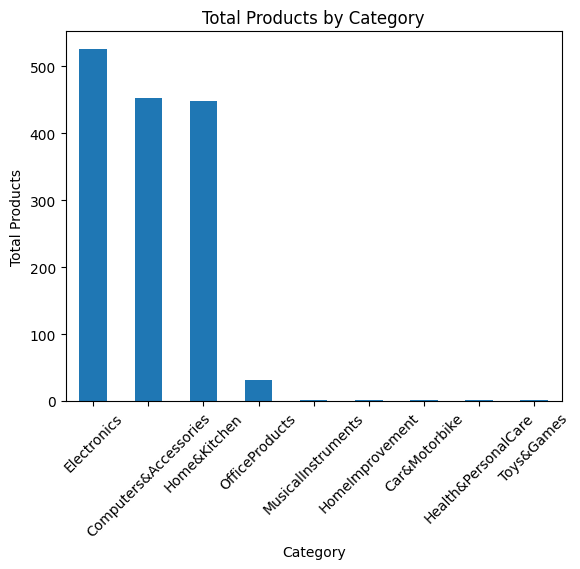

In [50]:
import matplotlib.pyplot as plt
product_count = df.groupby("main_category_lvl1")["product_name"].count().sort_values(ascending=False)

plt.figure()
product_count.plot(kind="bar")
plt.title("Total Products by Category")
plt.xlabel("Category")
plt.ylabel("Total Products")
plt.xticks(rotation=45)
plt.show()

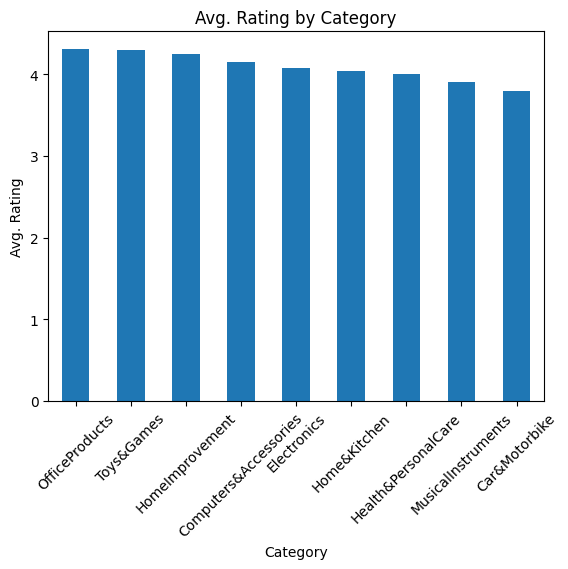

In [54]:
category_rating = df.groupby("main_category_lvl1")["rating"].mean().sort_values(ascending=False)

plt.figure()
category_rating.plot(kind="bar")
plt.title("Avg. Rating by Category")
plt.xlabel("Category")
plt.ylabel("Avg. Rating")
plt.xticks(rotation=45)
plt.show()

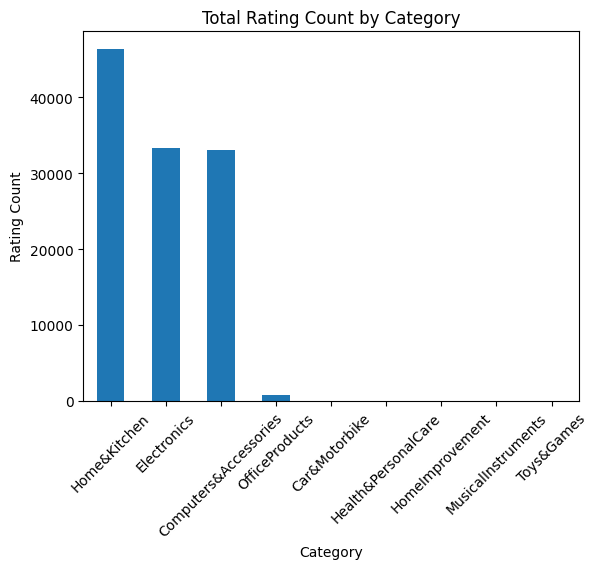

In [55]:
category_rating_count = df.groupby("main_category_lvl1")["rating_count"].sum().sort_values(ascending=False)

plt.figure()
category_rating_count.plot(kind="bar")
plt.title("Total Rating Count by Category")
plt.xlabel("Category")
plt.ylabel("Rating Count")
plt.xticks(rotation=45)
plt.show()

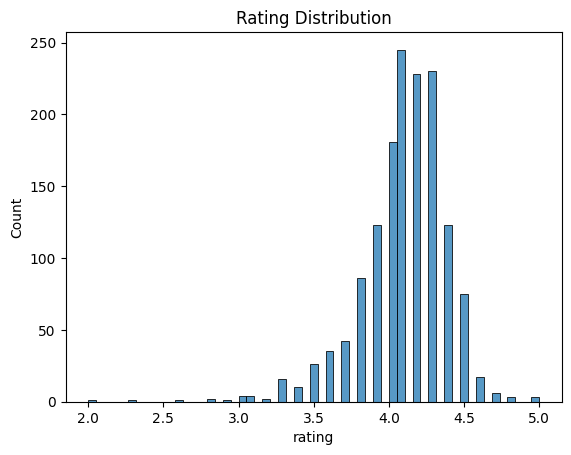

In [58]:
import seaborn as sns
plt.figure()
sns.histplot(df["rating"])
plt.title("Rating Distribution")
plt.show()

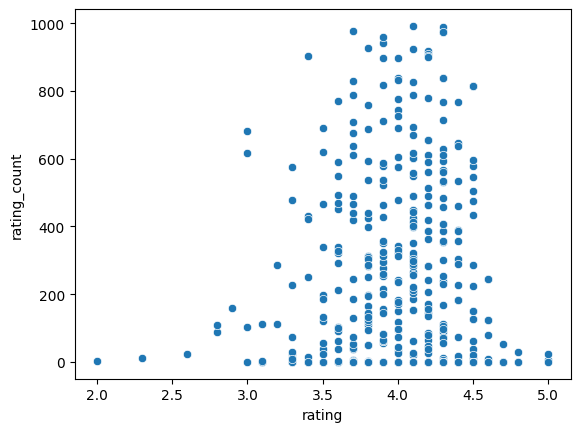

In [ ]:
plt.figure()
sns.scatterplot(x="rating", y="rating_count", data=df) # Visualizing relationship between product rating and rating count to understand correlation between quality and popularity
plt.show()

In [ ]:

df = df.drop(["category","main_category", "user_id","user_name","review_id","review_title","review_content","img_link","product_link"], axis=1) #Dropping unecessary columns

In [ ]:
df = df.rename(columns={"main_category_lvl1": "category"}) #Renaming the column

In [ ]:
df.to_csv("data/final_amazon_data.csv", index=False) #Saving the final data in a new file

In [ ]:
# ---------------------- FINAL INSIGHTS ---------------------- #

# The average product rating is approximately 4.1, indicating that most products
# receive generally positive customer feedback.

# The Electronics category has the highest number of products,
# showing a strong presence in the dataset.

# The Office Products category has the highest average rating (~4.3),
# suggesting higher customer satisfaction compared to other categories.

# The Home & Kitchen category shows the highest engagement with the largest
# total rating count, indicating strong customer interaction and demand.

# There is no strong correlation between rating and rating count,
# meaning highly rated products are not always the most popular.

# Many products have high ratings but low rating counts,
# indicating potential lack of visibility rather than poor quality.

# Products that have both high ratings and high rating counts are the most reliable
# and represent truly successful products.


# ------------------ BUSINESS RECOMMENDATIONS ------------------ #

# Sellers should focus on high-engagement categories like Home & Kitchen
# to maximize visibility and potential sales.

# Highly rated but low-engagement products should be promoted more
# to increase customer reach and awareness.

# Maintaining product quality while increasing the number of reviews
# is key to building reliable and successful products.